# **Atividade Prática**
<font size=3>

- **Tema:** máquinas de vetores de suporte.
- **Prazo de entrega:** 28 de Maio.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeHK5qrS-_wttHK6XXKBK2-SXv1nxU3Xhk8x__eP1ZrHulHDw/viewform?usp=header).

---

## **Enunciado:**
<font size=3>

Com base no *dataset* de [Doenças Cardíacas](https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos para resolver a tarefa de classificação:

### **1º Passo:**
<font size=3>

- Importe o *dataset* e **imprima na tela** o dataframe;
- Transformer o atributo `AgeCategory` para que o intervalo das idades seja definida como a média, *e.g.*, $[20,\, 40] \rightarrow 30$;
- Defina a variável alvo como `HeartDisease` e as demais como a variável de atributos.


In [90]:
import pandas as pd

# from google.colab import drive
# drive.mount('/content/drive') 

dataset = pd.read_csv("/content/drive/MyDrive/5 semestre /Aprendizado de maquina supervisionado/IMD3002 - Aprendizado de Máquina Supervisionado/2-unidade/dataset/heart_disease.csv")
dataset.head()


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,Yes,25.06,No,No,No,30.0,30.0,Yes,Female,60-64,White,Yes,No,Poor,10.0,No,No,No
1,No,24.39,No,No,No,0.0,0.0,No,Male,35-39,White,No,Yes,Excellent,8.0,No,No,No
2,No,33.91,Yes,Yes,No,30.0,30.0,No,Male,30-34,White,No,Yes,Poor,7.0,Yes,No,No
3,No,27.79,Yes,No,No,0.0,0.0,Yes,Female,55-59,White,No,Yes,Good,7.0,No,No,No
4,No,32.89,No,No,No,30.0,15.0,Yes,Female,75-79,White,Yes,Yes,Fair,8.0,No,No,No


In [91]:
import numpy as np
import re

def extract_mean_age(feature):
    feture_mean_age = []
    for i in feature:
        numeros = re.findall(r'\d+', str(i))
        numeros_int = int(np.mean([int(n) for n in numeros]))

        feture_mean_age.append(int(numeros_int))
    return feture_mean_age
    
dataset["AgeCategory"] = extract_mean_age(dataset["AgeCategory"])

dataset.head()



,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,Yes,25.06,No,No,No,30.0,30.0,Yes,Female,62,White,Yes,No,Poor,10.0,No,No,No
1,No,24.39,No,No,No,0.0,0.0,No,Male,37,White,No,Yes,Excellent,8.0,No,No,No
2,No,33.91,Yes,Yes,No,30.0,30.0,No,Male,32,White,No,Yes,Poor,7.0,Yes,No,No
3,No,27.79,Yes,No,No,0.0,0.0,Yes,Female,57,White,No,Yes,Good,7.0,No,No,No
4,No,32.89,No,No,No,30.0,15.0,Yes,Female,77,White,Yes,Yes,Fair,8.0,No,No,No


In [92]:
x = dataset.drop(columns=["HeartDisease"])
y = dataset["HeartDisease"]

### **2º Passo:**
<font size=3>

- Utilize a função `unique` do Numpy para identificar as proporções das classes da variável `y`;
- Realize a divisão dos dados entre treinamento e teste. Caso seja necessário, faça a estratificação;
- Utilize a classe [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar `y_train` e `y_test`;
- Para transformar os dados de atributos:
    - Defina o transformador ([`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)) dos dados categóricos;
    - Defina o transformador ([`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)) dos dados numéricos.
- Defina o objeto preprocessador com a classe [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html).

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

classes, contagens = np.unique(y, return_counts=True)
proporcoes = contagens / len(y)

print(dict(zip(classes, proporcoes)))

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)



{'No': np.float64(0.8104643104643104), 'Yes': np.float64(0.18953568953568953)}


In [94]:


features_categoricas = ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex','Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']
modelo_categorico = OneHotEncoder()

features_numericas = ['BMI', 'PhysicalHealth', 'MentalHealth', 'AgeCategory', 'SleepTime']
modelo_numerico = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
        ('Categoricas', modelo_categorico, features_categoricas),
        ('Numericas', modelo_numerico, features_numericas),
    ]
)


### **3º Passo:**
<font size=3>

- Defina o objeto de [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) para encadear o objeto preprocessador e o modelo de [máquina de vetores de suporte](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html);
- Para treinar o modelo, utilize a classe [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) considerando:
    - As funções kernels `linear`, `poly` e `rbf`, com seus principais hiperparâmetros;
    - 10 iterações na busca de hiperparâmetros;
    - 5 divisões para validação cruzada;
    - Métrica acurácia.
- **Imprima na tela** os melhores hiperparâmetros e valor de acurácia.    

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

param_distributions = {
    'classifier__kernel': ['linear', 'poly', 'rbf'],
    'classifier__C': uniform(0.1, 10),
    'classifier__gamma': ['scale', 'auto']
}


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  
    random_state=42,
    verbose=1
)
random_search.fit(x_train, y_train)



Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Categoricas',
                                                                               OneHotEncoder(),
                                                                               ['Smoking',
                                                                                'AlcoholDrinking',
                                                                                'Stroke',
                                                                                'DiffWalking',
                                                                                'Sex',
                                                                                'Race',
                                                                                'Diabetic',
                                                                                'PhysicalActivity',
                                                                                'GenHealth',
                                                                                'Asthma',
                                                                                'KidneyDisease',
                                                                                'SkinCancer']),
                                                                              ('Numericas',
                                                                               StandardScaler(),
                                                                               ['BMI',
                                                                                'PhysicalHealth',
                                                                                'MentalHealth',
                                                                                'AgeCategory',
                                                                                'SleepTime'])])),
                                             ('classifier', SVC())]),
                   n_jobs=-1,
                   param_distributions={'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a661180f1a0>,
                                        'classifier__gamma': ['scale', 'auto'],
                                        'classifier__kernel': ['linear', 'poly',
                                                               'rbf']},
                   random_state=42, scoring='accuracy', verbose=1)

In [96]:

print(f"Melhores hiperparâmetros: {random_search.best_params_}")
print(f"Melhor acurácia (validação cruzada): {random_search.best_score_:.4f}")

Melhores hiperparâmetros: {'classifier__C': np.float64(3.845401188473625), 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Melhor acurácia (validação cruzada): 0.8426


### **4º Passo:**
<font size=3>

- Realize as predições com os dados de teste;
- Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) e [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) para plotar a **matriz de confusão**;
- Utilize a função [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para **imprimir na tela** os resultados da classificação;
- **Escreva** em uma **célula _markdown_** sua interpretação dos resultados. 

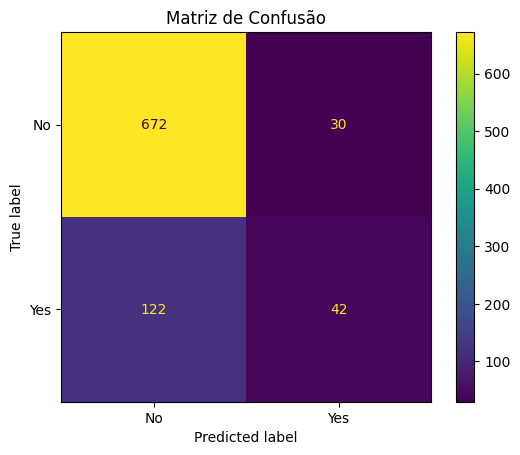

In [97]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_pred = random_search.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot()
plt.title("Matriz de Confusão")
plt.show()



In [98]:
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Relatório de Classificação:

              precision    recall  f1-score   support

          No       0.85      0.96      0.90       702
         Yes       0.58      0.26      0.36       164

    accuracy                           0.82       866
   macro avg       0.71      0.61      0.63       866
weighted avg       0.80      0.82      0.80       866



## Analise dos resultados:

Analisando da forma como que esta dividido as classes dos dados, este dataset tem cerca de 81% dos dados como não possui a doença e aproximadamente de 19% tem a doença. Nesse cenario, o modelo obteve 82% de acuracia olhando assim pesamos que o modelo esta ate que se saindo bem mesmo apesar de q se trata de dataset sobre uma doença esperavamos um valor ainda maior acima dos 90% tornado-se ate um valor preoculpante esse 82%. Entretando, o cenario piora quando analisamos a matriz de confusão e o relatorio, notei um ponto em especial ainda mais critico que apenas essa acuracia.

Aprincipio, por causa do dataset ter classes desbalanceados como muitos mais casos de não ter a doença do que casos de ter a doença apesar de ter feito a divisão dos dados estratificada acabou enviesando o modelo que podemos ver que ele é muito bom para detectar as pessoas q não tem a doença tendo 96% de recall e a prova que de fato esse desbalanceamento é que no recall para os casos de sim ele so teve 26% mosstrando que ele esta falhando para detectar a maioria dos casos em que de fato a pessoa tem a doença passando muitos falsos negatitvos como podemos ver na matriz de confusão e nesse cenario somente tem 58% de precisão de predict acertando pouco mais da metade das vezes.

Por tanto, mesmo que pela metrica da acuracia seja ate promissora sendo ate alta mas como falei no inicio ainda não boa o suficiente se tratando de um modelo que lida em classificar uma pessoa com ou sem uma doença, portanto com esses dados é melhor priorizar o recall do sim pois é mais grave n detectar que exite a doença um falso negativo que verificar se alguem não tem a doença um falso positivo, Seria preciso dar mais evidencia ou peso aos casos de de sim, mesmo q isso acabe prejudicando a acuracia global ou ate diminuindo as metricas de recal do não. pesquisando achei q se adicionar esse parametro class_weight='balanced' dentro do SVC podemos justamente dar esse peso as casos que tem a doença.

Com isso, o modelo passa a ser capaz de encontrar um pouco mais da metade dos pacientes que realmente têm a doença e com essa sensividade maior mesmo q ainda não no cenario ideal se tornou um pouco mais acertivo.
Afinal, o melhor cenario seria que ele deixar mais falsos positivos a ter a doença mas garantindo que mais pessoas ou todas as pessoas com a donça fossem detectadas mesmo que mais pessoas q n tem a doença passassem a ser caracterizadas com sim tambem. Afinal é melhor um diagnistico dizer quem tem a determinada doença e iniciar um diagnostico mais detalhado do que não ser diagnisticado preventivamente.

Fitting 5 folds for each of 10 candidates, totalling 50 fits


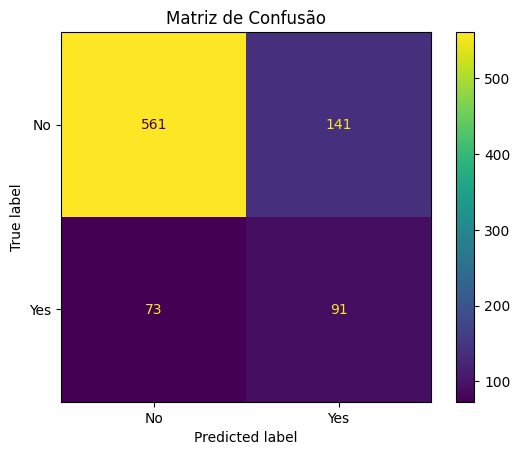

Relatório de Classificação:

              precision    recall  f1-score   support

          No       0.88      0.80      0.84       702
         Yes       0.39      0.55      0.46       164

    accuracy                           0.75       866
   macro avg       0.64      0.68      0.65       866
weighted avg       0.79      0.75      0.77       866



In [99]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(class_weight='balanced')) 
])


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  
    random_state=42,
    verbose=1
)
random_search.fit(x_train, y_train)

y_pred = random_search.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot()
plt.title("Matriz de Confusão")
plt.show()

print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))